# Semantic Segmentation — U-Net (Training)

Bagian **training** saja. Menghasilkan `best.pt` (weight terbaik) yang dipakai oleh notebook `semantic-segmentation-unet-serving.ipynb` yang terpisah. File weight tidak disertakan di repo (gitignored) — jalankan notebook ini untuk menghasilkannya sendiri.

## Prepare datasets

In [1]:
!wget https://github.com/ongchinkiat/LyftPerceptionChallenge/releases/download/v0.1/carla-capture-20180513A.zip

--2026-09-15 02:09:16--  https://github.com/ongchinkiat/LyftPerceptionChallenge/releases/download/v0.1/carla-capture-20180513A.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/133205941/81354846-56ca-11e8-90ae-c89ec7c24fe8?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-15T02%3A49%3A40Z&rscd=attachment%3B+filename%3Dcarla-capture-20180513A.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-15T01%3A49%3A16Z&ske=2026-09-15T02%3A49%3A40Z&sks=b&skv=2018-11-09&sig=RZUvfY3RDFTEw37ySrQiBvZlKIydrbTSnCBqSaWiCKs%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4OTQ0MTc1NiwibmJmIjoxNzg5NDM4MTU2LCJwYXRo

In [2]:
!unzip carla-capture-20180513A.zip -d data

Archive:  carla-capture-20180513A.zip
   creating: data/CameraRGB/
 extracting: data/CameraRGB/F61-1.png  
 extracting: data/CameraRGB/F61-10.png  
 extracting: data/CameraRGB/F61-100.png  
 extracting: data/CameraRGB/F61-11.png  
 extracting: data/CameraRGB/F61-12.png  
 extracting: data/CameraRGB/F61-13.png  
 extracting: data/CameraRGB/F61-14.png  
 extracting: data/CameraRGB/F61-15.png  
 extracting: data/CameraRGB/F61-16.png  
 extracting: data/CameraRGB/F61-17.png  
 extracting: data/CameraRGB/F61-18.png  
 extracting: data/CameraRGB/F61-19.png  
 extracting: data/CameraRGB/F61-2.png  
 extracting: data/CameraRGB/F61-20.png  
 extracting: data/CameraRGB/F61-21.png  
 extracting: data/CameraRGB/F61-22.png  
 extracting: data/CameraRGB/F61-23.png  
 extracting: data/CameraRGB/F61-24.png  
 extracting: data/CameraRGB/F61-25.png  
 extracting: data/CameraRGB/F61-26.png  
 extracting: data/CameraRGB/F61-27.png  
 extracting: data/CameraRGB/F61-28.png  
 extracting: data/CameraRGB/F61-

## Prepare the Dataloader

In [3]:
!pip install -q segmentation-models-pytorch
!pip install -q "torchmetrics>=1.6.0"  # Diperbaiki: DiceScore baru ada mulai 1.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.7 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
# Untuk Image Augmentation, lebih banyak variasi augmentasi dibandingkan torchvision
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import matplotlib.pyplot as plt
import cv2
# Untuk calculasi loss
import segmentation_models_pytorch as smp
import torchmetrics
from torchmetrics.segmentation import DiceScore  # API metrik yang lebih baru, dipakai bareng argmax

In [5]:
DATA_PATH = 'data'

## Mount Google Drive (untuk simpan `best.pt` secara persisten)

In [8]:
from google.colab import drive
drive.mount('/content/drive')

# Sesuaikan folder ini kalau mau lokasi lain di Drive kamu
DRIVE_MODEL_DIR = '/content/drive/MyDrive/AI-Engineer/CV/semantic-segmentation-unet'
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(DRIVE_MODEL_DIR, 'best.pt')

Mounted at /content/drive


In [9]:
class CityScapes(torch.utils.data.Dataset):
  def __init__(self,
               image_folder_path, # Path untuk ke inputan image RGB
               mask_folder_path, # Gambar label masking Ground Truthnya
               transforms=None):
    self.images_folder = image_folder_path
    self.masks_folder = mask_folder_path
    self.images = os.listdir(self.images_folder)

    self.transforms = transforms

  def __len__(self):
    return len(self.images)

  def __getitem__(self, index):
    file_name = self.images[index]
    # f61-1.png
    # Input img: CameraRGB/f61-1.png
    image = cv2.imread(os.path.join(self.images_folder, file_name))
    # Input img: CameraSEG/f61-1.png
    mask = cv2.imread(os.path.join(self.masks_folder, file_name))

    # Ubah ke RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = mask[:,:,2]

    if self.transforms is not None:
      augmented = self.transforms(image=image, mask=mask)
      image = augmented['image']
      mask = augmented['mask']

    return image, mask.unsqueeze(0)

In [10]:
transforms = A.Compose([

    A.Resize(256,256),# Resize gambarnya ke 256, 256
    A.Normalize(), # biar pixelnya 0-1
    ToTensorV2() # kita ubah formatnya ke tensor
])

In [11]:
data = CityScapes(os.path.join(DATA_PATH, "CameraRGB"), os.path.join(DATA_PATH, "CameraSeg"), transforms=transforms)

In [12]:
data[0][0].shape, data[0][1].shape, data[0][1].unique()

(torch.Size([3, 256, 256]),
 torch.Size([1, 256, 256]),
 tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=torch.uint8))

In [13]:
#how many classes inside the data
all_class = []
for i in range(len(data)):
  all_class.extend(data[i][1].unique().tolist())
all_class = list(set(all_class))

In [14]:
print(all_class)
print(len(data))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
1000


In [15]:
#split train and test
train_datasets, test_datasets = torch.utils.data.random_split(data, [0.8,0.2])

In [16]:
image, mask = train_datasets[0]
image.size(), mask.size()

(torch.Size([3, 256, 256]), torch.Size([1, 256, 256]))

## Model Architecture

In [17]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

In [18]:
class UNET(nn.Module):
    def __init__(
            self, in_channels=3, out_channels=1, features=[64, 128, 256, 512],
    ):
        super(UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # doblemconv, dobleconv..
        # Down part of UNET
        for feature in features:
            # 0: 3 -> 64
            # 1: 64 -> 128
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        #upsam, doubleconv, up, ..
        # Up part of UNET
        for feature in reversed(features):
            self.ups.append(#0
                nn.ConvTranspose2d(
                    feature*2, feature, kernel_size=2, stride=2,
                )
            )
            self.ups.append(DoubleConv(feature*2, feature))#1

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            # ngesave informasi
            skip_connections.append(x)
            # masuk maxpooling
            x = self.pool(x)

        # bagian yang paling kecil sbg transisi ke upsample
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1] # reversed(skip_connections)

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

## Engine

In [19]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    train_loss = 0.0

    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        target = target.squeeze(1)  # Diperbaiki: (N,1,H,W) -> (N,H,W), disamakan dengan evaluate()
        # kita reset gradient
        optimizer.zero_grad()

        # kita forward
        output = model(data)
        # Kita calculate loss -> loss: Dice Score
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    return train_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    eval_loss = 0.0
    # Diperbaiki: pakai DiceScore (API baru) + argmax, dan akumulasi via .update()/.compute()
    # supaya dice score dihitung dari keseluruhan dataset, bukan rata-rata kasar per-batch.
    dice_score_function = DiceScore(num_classes=13, average='micro', input_format='index').to(device)  # Diperbaiki: preds/target berupa index (N,H,W), bukan one-hot

    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(dataloader):
            data, target = data.to(device), target.to(device)
            target = target.squeeze(1)  # (N,1,H,W) -> (N,H,W)

            output = model(data)
            loss = criterion(output, target.long())
            eval_loss += loss.item()

            preds = torch.argmax(output, dim=1)
            dice_score_function.update(preds, target.long())

    dice_score = dice_score_function.compute()

    return eval_loss / len(dataloader), dice_score.item()

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNET(3, 13)

model.to(device)

UNET(
  (ups): ModuleList(
    (0): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2))
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
    (3): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), p

In [21]:
def train(model, train_datasets, test_datasets):
  train_dataloader = torch.utils.data.DataLoader(train_datasets, 8, True, num_workers=2)
  eval_dataloader = torch.utils.data.DataLoader(test_datasets, 8, False, num_workers=2)

  device = "cuda" if torch.cuda.is_available() else "cpu"

  criterion = smp.losses.DiceLoss(mode='multiclass')
  optimizer = torch.optim.Adam(model.parameters(), 1e-3)

  num_epochs = 200

  best_eval_loss = float('inf')

  for epoch in range(num_epochs):
      # Training
      train_loss = train_epoch(model, train_dataloader, criterion, optimizer, device)

      # Evaluation
      eval_loss, dice_score = evaluate(model, eval_dataloader, criterion, device)

      # Print results
      print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Eval Loss = {eval_loss:.4f}, Dice Score = {dice_score:.4f}")
      # print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Eval Loss = {eval_loss:.4f}")

      if eval_loss < best_eval_loss:
        best_eval_loss = eval_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)

> **Catatan:** fungsi `train_epoch`/`evaluate` di atas sudah diperbaiki (target di-squeeze konsisten, pakai `DiceScore` + `argmax`). Log training 22 epoch di bawah ini masih dari **run lama sebelum perbaikan ini** (dipertahankan sebagai riwayat) — perlu di-re-run ulang untuk angka yang valid dengan kode yang sudah diperbaiki.

In [22]:
train(model, train_datasets, test_datasets)

/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


Epoch 1: Train Loss = 0.6750, Eval Loss = 0.6016, Dice Score = 0.8149
Epoch 2: Train Loss = 0.4822, Eval Loss = 0.4579, Dice Score = 0.8763
Epoch 3: Train Loss = 0.3812, Eval Loss = 0.3563, Dice Score = 0.9201
Epoch 4: Train Loss = 0.3454, Eval Loss = 0.3377, Dice Score = 0.9187
Epoch 5: Train Loss = 0.3201, Eval Loss = 0.3134, Dice Score = 0.9248
Epoch 6: Train Loss = 0.2922, Eval Loss = 0.3261, Dice Score = 0.9121
Epoch 7: Train Loss = 0.2850, Eval Loss = 0.2750, Dice Score = 0.9354
Epoch 8: Train Loss = 0.2630, Eval Loss = 0.2806, Dice Score = 0.9316
Epoch 9: Train Loss = 0.2498, Eval Loss = 0.2552, Dice Score = 0.9407
Epoch 10: Train Loss = 0.2433, Eval Loss = 0.2439, Dice Score = 0.9395
Epoch 11: Train Loss = 0.2338, Eval Loss = 0.2416, Dice Score = 0.9413
Epoch 12: Train Loss = 0.2315, Eval Loss = 0.2271, Dice Score = 0.9465
Epoch 13: Train Loss = 0.2270, Eval Loss = 0.2408, Dice Score = 0.9443
Epoch 14: Train Loss = 0.2174, Eval Loss = 0.2200, Dice Score = 0.9498
Epoch 15: Train

## Visualize Prediction

In [24]:
sample = test_datasets[0]

In [25]:
x = sample[0].to('cuda').unsqueeze(0)
out = model(x)

In [26]:
out

tensor([[[[ 11.9492,  15.7287,  19.5913,  ...,   4.5411,   2.0946,   1.5136],
          [ 20.5172,  26.3105,  30.9412,  ...,  -0.3921,   3.7462,   4.0494],
          [ 16.1675,  25.1338,  27.6185,  ...,  -5.2726,  -6.9122,  -2.4507],
          ...,
          [-10.4533,  -6.4077,  -2.1978,  ...,  -2.8179,  -2.5771,  -3.8946],
          [ -9.7065,  -9.5972,  -7.2479,  ...,  -8.4853,  -5.0969,  -5.1844],
          [ -8.7342,  -8.5549,  -8.1092,  ...,  -6.4716,  -6.3163,  -6.7096]],

         [[-12.6151, -22.8901, -30.7170,  ...,  15.1455,  15.7321,  12.2526],
          [-13.6244, -22.8140, -31.3093,  ...,  14.8385,  14.5958,  15.1702],
          [-17.2075, -28.5995, -41.7393,  ...,  19.9108,  17.6142,  17.8927],
          ...,
          [-13.0729, -22.0044, -21.4694,  ..., -23.8370, -30.3837, -17.7570],
          [-11.3725, -19.9267, -25.0667,  ..., -30.3027, -37.5089, -23.0541],
          [-11.4977, -12.0646, -13.6422,  ..., -20.0837, -21.8130, -12.1795]],

         [[-10.5269,  -6.6876,

In [27]:
out.shape

torch.Size([1, 13, 256, 256])

In [28]:
def common_encoding(one_hot):
    num_classes, height, width = one_hot.shape
    common_mask = torch.zeros((height, width), dtype=torch.int64)

    for class_idx in range(1, num_classes):
        class_mask = (one_hot[class_idx] == 1).nonzero(as_tuple=True)
        common_mask[class_mask] = class_idx

    return common_mask

In [29]:
def rgb_encoding(common_mask):
    color_dict = {
        0: (255, 0, 0),     # Red
        1: (0, 255, 0),     # Green
        2: (0, 0, 255),     # Blue
        3: (255, 255, 0),   # Yellow
        4: (255, 0, 255),   # Magenta
        5: (0, 255, 255),   # Cyan
        6: (128, 0, 0),     # Maroon
        7: (0, 128, 0),     # Dark Green
        8: (0, 0, 128),     # Navy
        9: (128, 128, 0),  # Olive
        10: (128, 0, 128),  # Purple
        11: (0, 128, 128),   # Teal
        12: (56, 128, 0)
    }

    num_classes = torch.max(common_mask).item() + 1
    rgb_mask = torch.zeros((3, common_mask.shape[0], common_mask.shape[1]), dtype=torch.uint8)

    for class_idx in range(1, num_classes):
        if class_idx in color_dict:
            class_color = color_dict[class_idx]
            class_mask = (common_mask == class_idx)

            for channel in range(3):
                rgb_mask[channel][class_mask] = class_color[channel]

    return rgb_mask.permute(1, 2, 0)

In [30]:
def postprocess(out):
  # Diperbaiki: pakai argmax per piksel (bukan threshold manual) supaya tiap
  # piksel selalu dapat tepat satu kelas yang deterministik.
  out = out.squeeze(0)
  common_mask = torch.argmax(out, dim=0)
  out = rgb_encoding(common_mask)
  return out

> **Catatan audit (before/after fix):** Output pada 2 cell di bawah ini (tensor semua nol & gambar hitam polos) dihasilkan dari **kode SEBELUM diperbaiki** (threshold manual `out>=thr`), sengaja dipertahankan sebagai bukti temuan bug — padahal model ini mencapai Dice Score ~95% saat training. Setelah fix `argmax` di atas, notebook perlu di-re-run untuk melihat hasil segmentasi yang benar.

In [31]:
postprocess(out)

tensor([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0, 255,   0],
         [  0, 255,   0],
         [  0, 255,   0]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0, 255,   0],
         [  0, 255,   0],
         [  0, 255,   0]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0, 255,   0],
         [  0, 255,   0],
         [  0, 255,   0]],

        ...,

        [[128,   0, 128],
         [128,   0, 128],
         [128,   0, 128],
         ...,
         [128,   0, 128],
         [128,   0, 128],
         [128,   0, 128]],

        [[128,   0, 128],
         [128,   0, 128],
         [128,   0, 128],
         ...,
         [128,   0, 128],
         [128,   0, 128],
         [128,   0, 128]],

        [[128,   0, 128],
         [128,   0, 128],
         [128,   0, 128],
         ...,
         [128,   0, 128],
        

In [32]:
out.size()

torch.Size([1, 13, 256, 256])

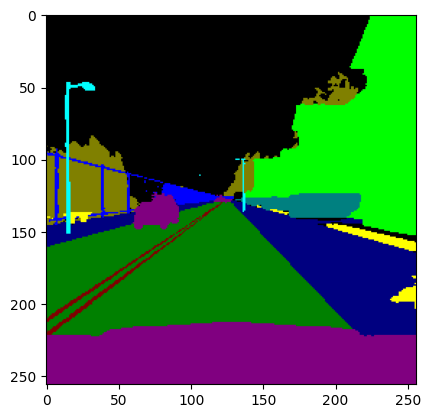

In [33]:
out2 = postprocess(out)
plt.imshow(out2)
plt.show()

tensor([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 10, 11], dtype=torch.uint8)


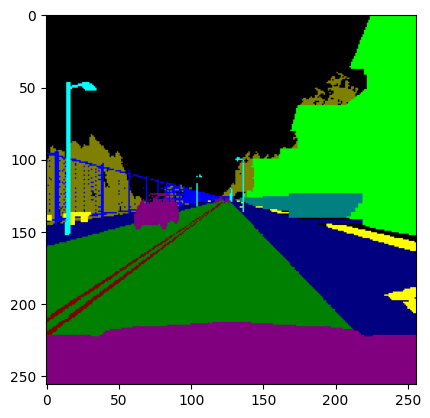

In [34]:
target = sample[1]
print(target.unique())
target = target.squeeze(0)
target = rgb_encoding(target)
plt.imshow(target)
plt.show()

---

Materi: rubythalib.ai — AI Super Class (Computer Vision, Sesi 4: Semantic Segmentation).
Mentor: Daniel Syahputra.